In [1]:
import numpy as np

# This would be a big datset
# from sklearn.datasets import make_s_curve
# X_scurve, color_scurve = make_s_curve(n_samples=1000,random_state=42,noise=0.05)
# X_centered = X_scurve - X_scurve.mean(axis=0)
# U, sum, Vt = np.linalg.svd(X_centered)

In [2]:
# smaller dataset
rng = np.random.default_rng(seed=42)
m = 60
angles = (rng.random(m)** 3 +0.5) * np.pi * 2 #for uneven distribution
X = np.zeros((m,3))
X[:,0],X[:,1] = np.cos(angles), np.sin(angles) * 0.5 #oval
X += 0.28 * rng.standard_normal((m,3))
X += [0.2,0,0.2] # shifts a bit

In [3]:
X_centered = X - X.mean(axis=0)
U,s,Vt = np.linalg.svd(X_centered)

In [4]:
print(f"Principal Component: {Vt[0]}")
print(f" Principal Component: {Vt[1]}") 
print(f" Principal Component: {Vt[2]}") 
print(f"eigen vectors: {Vt.shape}")

Principal Component: [-0.99772697 -0.0444333   0.05066132]
 Principal Component: [ 0.04103366 -0.99695714 -0.06627747]
 Principal Component: [-0.05345209  0.064048   -0.99651429]
eigen vectors: (3, 3)


In [5]:
print(f"eigen vector: {U.shape}")
# print(f" eigen vector: {U[1]}") 
# print(f" eigen vector: {U[2]}") 

eigen vector: (60, 60)


In [6]:
W2 = Vt[:2].T
X_2D = X_centered @ W2

### **Using PCA class of the decomposition library**

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2) # no. of principal components
X_2D = pca.fit_transform(X)

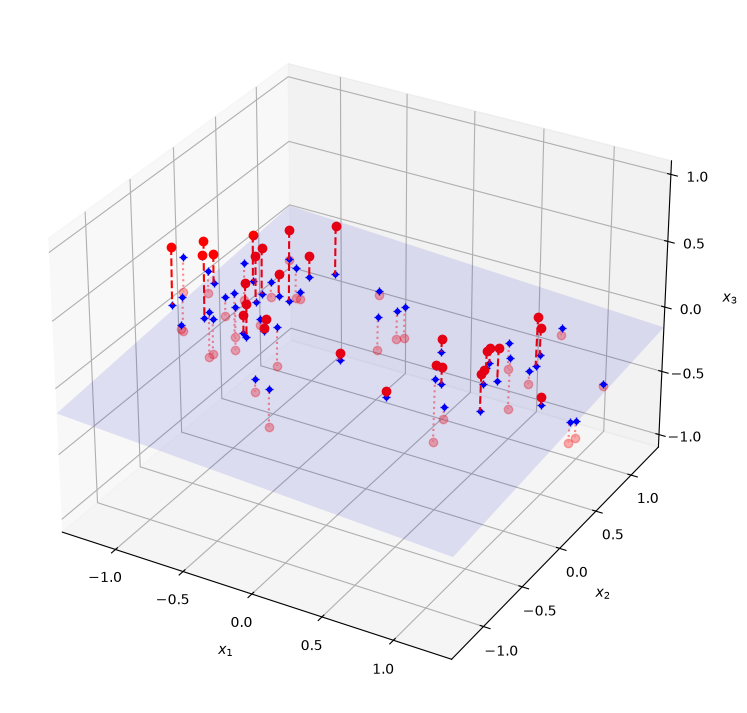

In [8]:
import matplotlib.pyplot as plt

X3D_inv = pca.inverse_transform(X_2D) 

axes = [-1.4, 1.4, -1.4, 1.4, -1.1, 1.1]
x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 10),
                     np.linspace(axes[2], axes[3], 10))
w1, w2 = np.linalg.solve(Vt[:2, :2], Vt[:2, 2])  # projection plane coefs
z = w1 * (x1 - pca.mean_[0]) + w2 * (x2 - pca.mean_[1]) - pca.mean_[2]  # plane
X3D_above = X[X[:, 2] >= X3D_inv[:, 2]]  # samples above plane
X3D_below = X[X[:, 2] < X3D_inv[:, 2]]  # samples below plane

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")

# plot samples and projection lines below plane first
ax.plot(X3D_below[:, 0], X3D_below[:, 1], X3D_below[:, 2], "ro", alpha=0.3)
for i in range(m):
    if X[i, 2] < X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], ":", color="#F88")

ax.plot_surface(x1, x2, z, alpha=0.1, color="b")  # projection plane
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b+")  # projected samples
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b.")

# now plot projection lines and samples above plane
for i in range(m):
    if X[i, 2] >= X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], "r--")

ax.plot(X3D_above[:, 0], X3D_above[:, 1], X3D_above[:, 2], "ro")

def set_xyz_axes(ax, axes):
    ax.xaxis.set_rotate_label(False)
    ax.yaxis.set_rotate_label(False)
    ax.zaxis.set_rotate_label(False)
    ax.set_xlabel("$x_1$", labelpad=8, rotation=0)
    ax.set_ylabel("$x_2$", labelpad=8, rotation=0)
    ax.set_zlabel("$x_3$", labelpad=8, rotation=0)
    ax.set_xlim(axes[0:2])
    ax.set_ylim(axes[2:4])
    ax.set_zlim(axes[4:6])

set_xyz_axes(ax, axes)
ax.set_zticks([-1, -0.5, 0, 0.5, 1])


plt.show()

In [9]:
pca.explained_variance_ratio_

array([0.82279334, 0.10821224])

This output tells us that about 82% of the dataset’s variance lies along the first PC, and about 11% lies along the second PC. This leaves about 7% for the third PC, so it is reasonable to assume that the third PC probably carries little information.


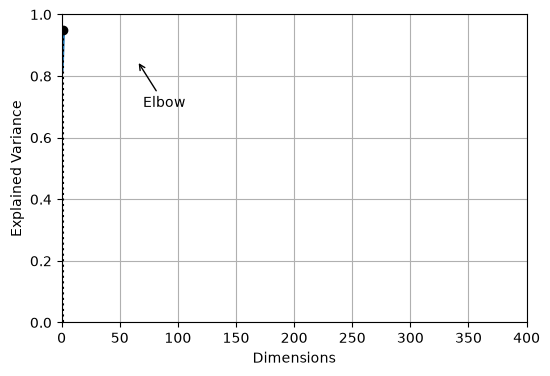

In [11]:
# extra code – this cell generates Figure 7–8

cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1 

plt.figure(figsize=(6, 4))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 400, 0, 1])
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops=dict(arrowstyle="->"))
plt.grid(True)


In [12]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1

In [13]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

In [14]:
pca.n_components

0.95

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))
param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,random_state=42)
rnd_search.fit(X_train[:1000],y_train[:1000])

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'pca__n_components': array([10, 11... 78, 79]), 'randomforestclassifier__n_estimators': array([ 50, ...97, 498, 499])}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metr

In [16]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}


It’s interesting to note how low the optimal number of components is: we reduced a 784-dimensional dataset to just 57 dimensions! This is tied to the fact that we used a random forest, which is a pretty powerful model. If we used a linear model instead, such as an SGDClassifier, the search would find that we need to preserve more dimensions (about 75).

The inverse_transform() method lets us decompress the reduced MNIST dataset back to 784 dimensions

In [17]:
X_recovered = pca.inverse_transform(X_reduced)
X_recovered.shape

(60000, 784)

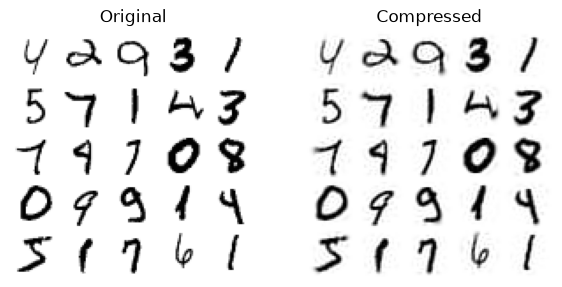

In [18]:
plt.figure(figsize=(7, 4))
for idx, X in enumerate((X_train[::2100], X_recovered[::2100])):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Compressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(X[row * 5 + col].reshape(28, 28), cmap="binary",
                       vmin=0, vmax=255, extent=(row, row + 1, col, col + 1))
            plt.axis([0, 5, 0, 5])
            plt.axis("off")

In [19]:
randomized_pca = PCA(random_state=42,n_components=154,svd_solver='randomized')
X_reduced_randomized = randomized_pca.fit(X_train)


In [20]:
from sklearn.decomposition import IncrementalPCA
n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)
X_reduced_Ince = inc_pca.transform(X_train)

Alternatively, you can use NumPy’s memmap class, which allows you to manipulate a large array stored in a binary file on disk as if it were entirely in memory; the class loads only the data it needs in memory, when it needs it. To demonstrate this, let’s first create a memory-mapped (memmap) file and copy the MNIST training set to it, then call flush() to ensure that any data still in the cache gets saved to disk.

In [ ]:
filename = "my_mnist.mmap" # always delete file else will throw error
X_mmap = np.memmap(filename, dtype='float32', mode='w+', shape=X_train.shape)
X_mmap[:] = X_train  # could be a loop instead, saving the data chunk by chunk
X_mmap.flush()

In [23]:
X_mmap = np.memmap(filename, dtype="float32", mode="readonly").reshape(-1, 784)
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

,"n_components n_components: int, default=NoneNumber of components to keep. If ``n_components`` is ``None``,then ``n_components`` is set to ``min(n_samples, n_features)``.",154
,"batch_size batch_size: int, default=NoneThe number of samples to use for each batch. Only used when calling``fit``. If ``batch_size`` is ``None``, then ``batch_size``is inferred from the data and set to ``5 * n_features``, to provide abalance between approximation accuracy and memory consumption.",600
,"whiten whiten: bool, default=FalseWhen True (False by default) the ``components_`` vectors are dividedby ``n_samples`` times ``components_`` to ensure uncorrelated outputswith unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimesimprove the predictive accuracy of the downstream estimators bymaking data respect some hard-wired assumptions.",False
,"copy copy: bool, default=TrueIf False, X will be overwritten. ``copy=False`` can be used tosave memory but is unsafe for general use.",True
Name,Type,Value
batch_size_ batch_size_: intInferred batch size from ``batch_size``.,int,600
"components_ components_: ndarray of shape (n_components, n_features)Principal axes in feature space, representing the directions ofmaximum variance in the data. Equivalently, the right singularvectors of the centered input data, parallel to its eigenvectors.The components are sorted by decreasing ``explained_variance_``.","ndarray[float64](154, 784)","[[-0., 0.,-0.,..., 0., 0., 0.], [-0.,-0., 0.,...,-0.,-0.,-0.], [-0.,-0., 0.,...,-0.,-0.,-0.], ..., [-0.,-0.,-0.,...,-0.,-0.,-0.], [ 0., 0.,-0.,...,-0.,-0.,-0.], [ 0., 0.,-0.,..., 0., 0., 0.]]"
"explained_variance_ explained_variance_: ndarray of shape (n_components,)Variance explained by each of the selected components.","ndarray[float64](154,)","[332724.64,243283.89,211507.31,..., 1448.24, 1407.4 , 1399.21]"
"explained_variance_ratio_ explained_variance_ratio_: ndarray of shape (n_components,)Percentage of variance explained by each of the selected components.If all components are stored, the sum of explained variances is equalto 1.0.","ndarray[float64](154,)","[0.1 ,0.07,0.06,...,0. ,0. ,0. ]"
"mean_ mean_: ndarray of shape (n_features,)Per-feature empirical mean, aggregate over calls to ``partial_fit``.","ndarray[float64](784,)","[0.,0.,0.,...,0.,0.,0.]"
n_components_ n_components_: intThe estimated number of components. Relevant when``n_components=None``.,int,154


In [24]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim
m,E = 5000,0.1
d = johnson_lindenstrauss_min_dim(m,eps=E)
print(f"Number of Dimensions: {d}")

Number of Dimensions: 7300


In [25]:
n = 20000
rng = np.random.default_rng(seed=42)
Projections = rng.standard_normal((d,n)) / np.sqrt(d)
X = rng.standard_normal((m,n)) # generates a fake dataset

In [26]:
X_reduced_proj = X @ Projections.T
X_reduced_proj.shape

(5000, 7300)

In [27]:
from sklearn.random_projection import GaussianRandomProjection
gauss_rand_proj = GaussianRandomProjection(eps=E,random_state=42)
X_reduced_gauss = gauss_rand_proj.fit_transform(X)
X_reduced_gauss

array([[ 1.69408337,  2.41661036, -4.5860355 , ..., -1.78339069,
         1.42895041,  0.74108623],
       [ 0.71333804,  2.361083  , -2.16506292, ...,  0.49408746,
         1.74363846,  3.16601553],
       [ 0.28760118, -0.35310548,  1.87177017, ..., -1.69895869,
         1.16883402,  1.46712174],
       ...,
       [-0.4949278 , -1.19382951, -0.4765139 , ..., -1.23322728,
        -2.21730776, -1.6433068 ],
       [-0.36901595,  3.40143749,  2.66287849, ..., -0.56137387,
         3.60130445, -0.00631796],
       [ 1.49629324,  0.69195618,  0.43616236, ...,  1.59879961,
         0.71518385, -1.40110923]], shape=(5000, 7300))